This script provides an example of plotting unstructured MUSICA simulation outputs for:
1. ne30np4 (~1-degree global)
2. ne30CONUSne30x8 (~14 km within CONUS and ~1-degree global)

# Read in defined functions and related files

In [ ]:
import os
import glob
import fnmatch

import pandas as pd
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point, Polygon

import xarray as xr
import numpy as np

import matplotlib.pyplot as plt # Core library for plotting
import matplotlib.cm as cm # To use different colormaps
import cartopy.crs as ccrs # For map projection
import seaborn as sns # boxplot

from matplotlib.cm import ScalarMappable

In [ ]:
# ============================================================
# CONFIGURATION - paths come from config/paths.py, the single source of
# truth. The SCRIP grids ship with the repository, so nothing outside it
# is needed to plot.
# ============================================================
import sys, pathlib
_here = pathlib.Path.cwd().resolve()
_ROOT = next(p for p in [_here, *_here.parents]
             if (p / 'config' / 'paths.py').exists())
sys.path.insert(0, str(_ROOT))
import config  # also puts functions/ on sys.path
from config.paths import SCRIP_NE30NP4, SCRIP_NE0CONUSNE30X8, case_hist_dir

from Plot_2D import Plot_2D   # from functions/

SCRIP_ne30np4         = str(SCRIP_NE30NP4)
SCRIP_ne30CONUSne30x8 = str(SCRIP_NE0CONUSNE30X8)


In [ ]:
region_bounds = {
        "CONUS": {"lon_range": [-140, -50], "lat_range": [15, 60]},
        "Global": {"lon_range": None, "lat_range": None},
    }

# Example for plotting

In [ ]:
# Example monthly-mean (h0) files from two runs. Point `case` at any case in
# your archive; case_hist_dir() resolves it through config/paths.py.

# ne30np4 (~1 deg global)
case_ne30np4 = 'f.e22.FCnudged.ne30_ne30_mg17.BGO3.BASEY20230401TY20231101'
File_ne30np4 = case_hist_dir(case_ne30np4) / f'{case_ne30np4}.cam.h0.2023-07.nc'
ds_ne30np4 = xr.open_dataset(File_ne30np4)

# ne0CONUSne30x8 (~14 km over CONUS, ~1 deg global)
case_ne30CONUS = 'f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.1MJuly.TS1basehourlyNEI2017'
File_ne30CONUSne30x8 = case_hist_dir(case_ne30CONUS) / f'{case_ne30CONUS}.cam.h0.2018-07.nc'
ds_ne30CONUSne30x8 = xr.open_dataset(File_ne30CONUSne30x8)


## ne30np4

In [ ]:
ds_ne30np4

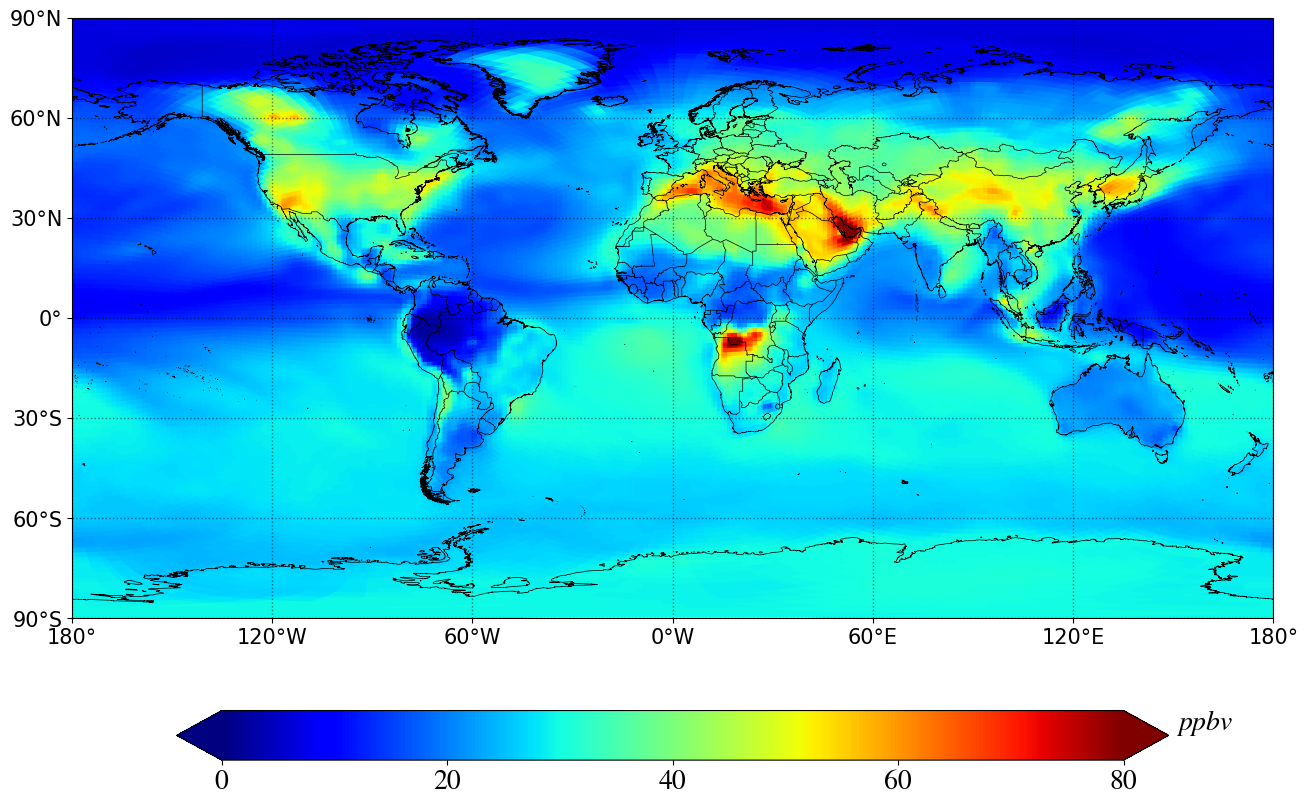

In [ ]:
# plot use the defined function with the specified scrip file; -1 for ilev at the surface
Plot_2D( ds_ne30np4['O3'][0,-1,:]*1e9, scrip_file=SCRIP_ne30np4, cmax=80, unit='ppbv' )

## ne30CONUSne30x8

In [ ]:
ds_ne30CONUSne30x8

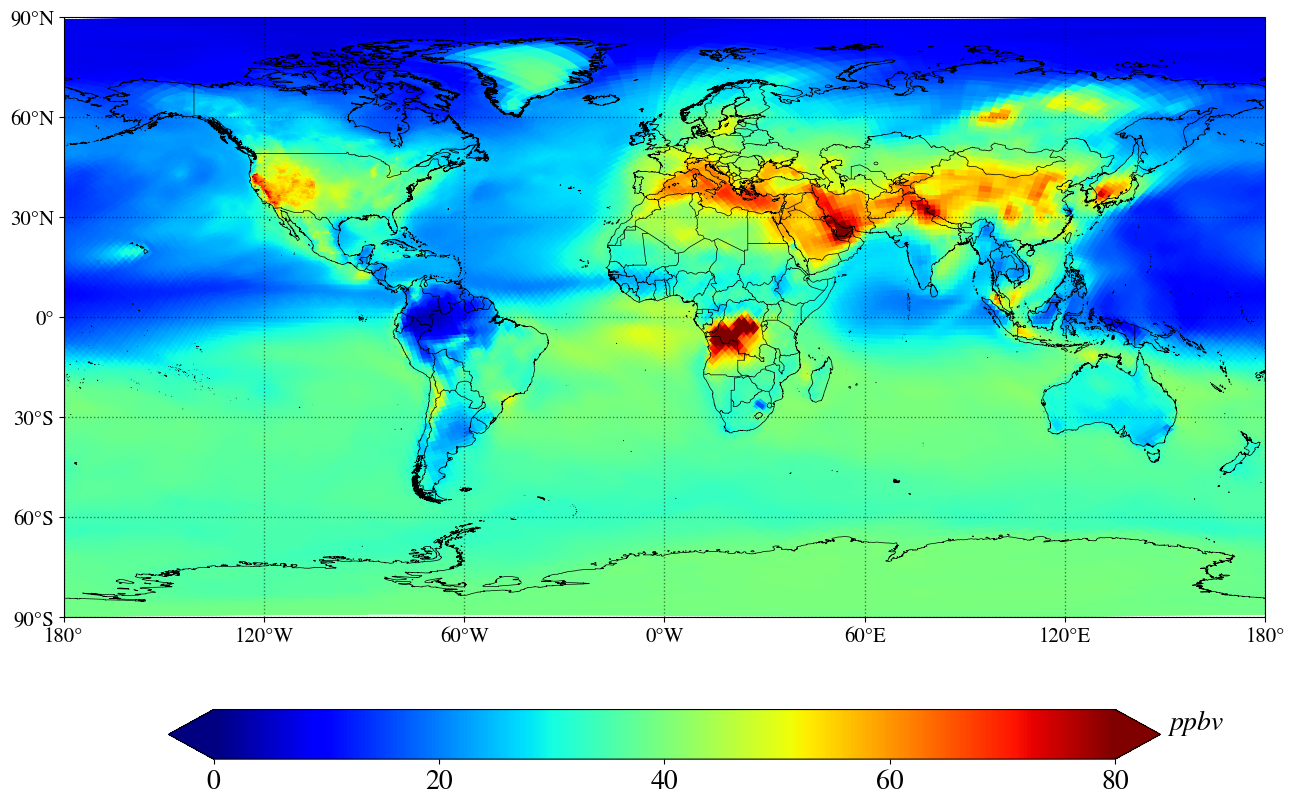

In [ ]:
# plot use the defined function with the specified scrip file; -1 for ilev at the surface
Plot_2D( ds_ne30CONUSne30x8['O3'][0,-1,:]*1e9, scrip_file=SCRIP_ne30CONUSne30x8, cmax=80, unit='ppbv' )